In [1]:
# Handle imports
import os
import torch
from torchvision import models
import torch.nn as nn
from sklearn.preprocessing import LabelEncoder
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import time
import kagglehub
import utils
from tqdm import tqdm
import copy
import matplotlib.pyplot as plt

In [2]:
print("####################################################################################")
print("Hello!!! Thank you for using OCT Classification.")
env = input("Please tell me if you are running code on Kaggle, colab or Local? (kaggle/colab/local): ").strip().lower()

model_name="densenet"
prev_stage=None

path_final_models, path_hackathon_checkpoints, path_plots, path_oct_models = utils.create_paths(model_name, augmented=True, env=env)

####################################################################################
Hello!!! Thank you for using OCT Classification.
Please tell me if you are running code on Kaggle, colab or Local? (kaggle/colab/local): colab
Mounted at /content/drive
Running in Colab environment.
The path are:
Final Models: /content/drive/MyDrive/Final_Models/densenet_aug
Hackathon Checkpoints: /content/drive/MyDrive/hackathon_checkpoints/densenet_aug
Plots: /content/drive/MyDrive/plots/densenet_aug
OCT Models: /content/drive/MyDrive/oct_models/densenet_aug


In [3]:
# Download dataset if needed
DATA_PATH = kagglehub.dataset_download("mislamshawon/oct2017")
print("####################################################################################")
print("The path for the dataset is:", DATA_PATH)
print("####################################################################")

# Check folder exists
if os.path.exists(DATA_PATH):
    print("Data folder contents:", os.listdir(os.path.join(DATA_PATH)))
    print("####################################################################")
    print("Train folder contents:", os.listdir(os.path.join(DATA_PATH, "train")))
    print("####################################################################")
    print("Val folder contents:", os.listdir(os.path.join(DATA_PATH, "val")))
    print("####################################################################")
    print("Test folder contents:", os.listdir(os.path.join(DATA_PATH, "test")))
    print("####################################################################")
else:
    print("Path does not exist!")

# Set random seed = 42
rand_seed = 42
np.random.seed(rand_seed)
torch.manual_seed(rand_seed)
torch.cuda.manual_seed_all(rand_seed)

Using Colab cache for faster access to the 'oct2017' dataset.
####################################################################################
The path for the dataset is: /kaggle/input/oct2017
####################################################################
Data folder contents: ['val', 'test', 'train']
####################################################################
Train folder contents: ['DRUSEN', 'CNV', 'NORMAL', 'DME']
####################################################################
Val folder contents: ['DRUSEN', 'CNV', 'NORMAL', 'DME']
####################################################################
Test folder contents: ['DRUSEN', 'CNV', 'NORMAL', 'DME']
####################################################################


In [4]:
# Create separate DataFrames
train_df = utils.create_dataframe("train", DATA_PATH)
val_df   = utils.create_dataframe("val", DATA_PATH)
test_df  = utils.create_dataframe("test", DATA_PATH)

sum_total_data = len(train_df)+len(val_df)+len(test_df)
print("####################################################################")
print("The total images in the dataset are:", (sum_total_data), "images")
print("####################################################################")

print("####################################################################")
print("The size of the imported data in each folder is:")
print("A) Train size:", len(train_df),"images [",len(train_df)/(sum_total_data) *100,"% ]")
print("B) Validation size:", len(val_df),"images [",len(val_df)/(sum_total_data) *100,"% ]")
print("C) Test size:", len(test_df),"images [",len(test_df)/(sum_total_data) *100,"% ]")
print("####################################################################")

####################################################################
The total images in the dataset are: 84130 images
####################################################################
####################################################################
The size of the imported data in each folder is:
A) Train size: 50580 images [ 60.12124093664567 % ]
B) Validation size: 16851 images [ 20.029715915844527 % ]
C) Test size: 16699 images [ 19.849043147509807 % ]
####################################################################


In [5]:
# Encode Labels to Numbers
le = LabelEncoder()

train_df["label_encoded"] = le.fit_transform(train_df["label"])
val_df["label_encoded"] = le.transform(val_df["label"])
test_df["label_encoded"] = le.transform(test_df["label"])
print("####################################################################")
print("The names of the classes in OCT classification are:")
print("Classes:", le.classes_)
print("Classes have been labeled as 0, 1, 2, 3.")
print("####################################################################")

####################################################################
The names of the classes in OCT classification are:
Classes: ['CNV' 'DME' 'DRUSEN' 'NORMAL']
Classes have been labeled as 0, 1, 2, 3.
####################################################################


In [6]:
# Image transformation
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0,translate=(0.05, 0.05),scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.2,contrast=0.2),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

transform_val_test = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [7]:
# Pass Transform Into Dataset
train_dataset = utils.OCTDataset(train_df, transform=transform)
val_dataset = utils.OCTDataset(val_df, transform=transform_val_test)
test_dataset = utils.OCTDataset(test_df, transform=transform_val_test)

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_names = ["CNV", "DME", "DRUSEN", "NORMAL"]

# Model Setup
model = models.densenet121(weights=None)
model.classifier = torch.nn.Linear(model.classifier.in_features, len(class_names))
model.load_state_dict(torch.load(f"{path_final_models}/densenet_refined.pth", map_location=device))
model = model.to(device)

In [9]:
# Define test_loader
test_loader = DataLoader(test_dataset, batch_size=512, num_workers=8, persistent_workers=True,
                          prefetch_factor=2, shuffle=True, pin_memory=True)

In [11]:
from importlib import reload
reload(utils)

<module 'utils' from '/content/utils.py'>

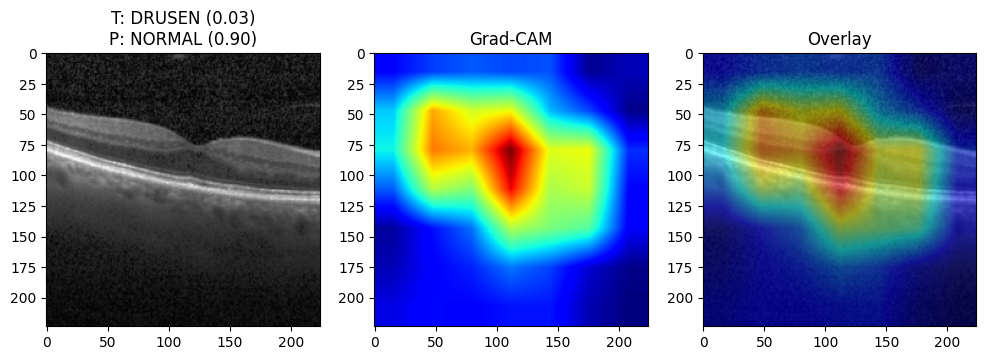

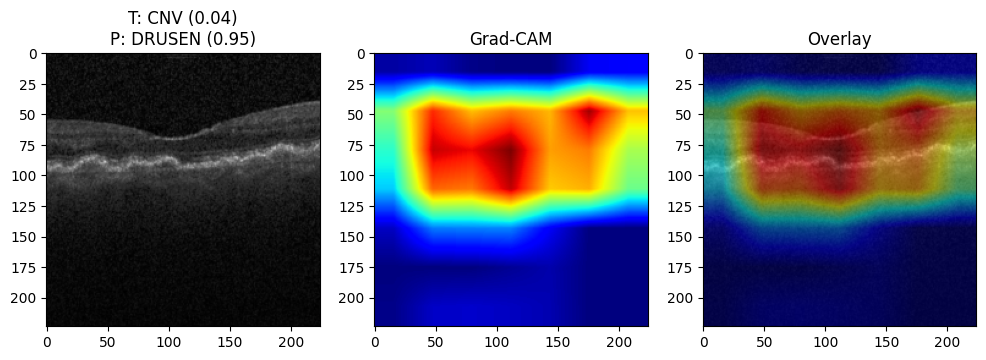

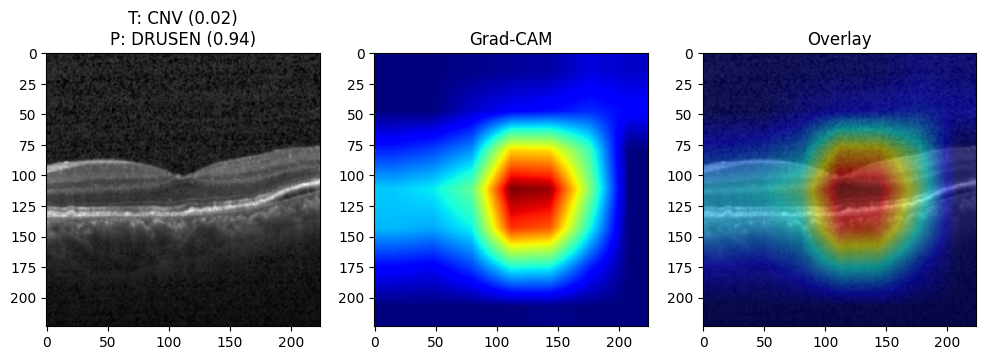

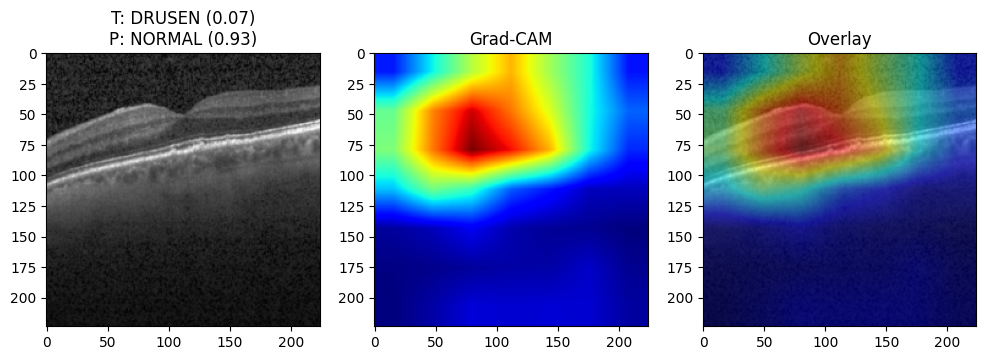

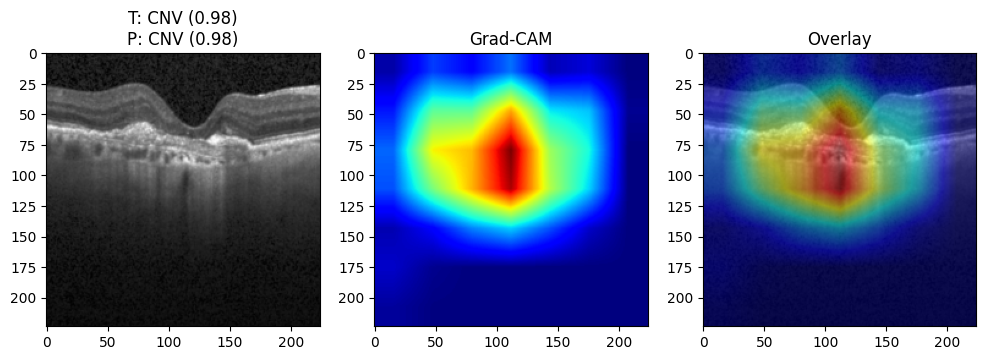

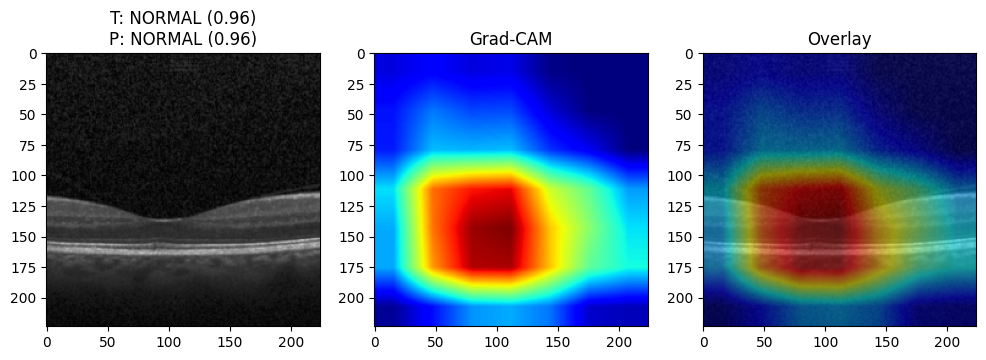

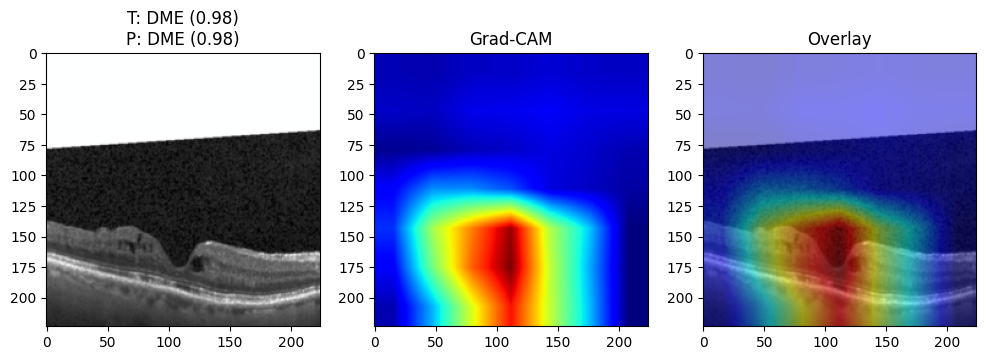

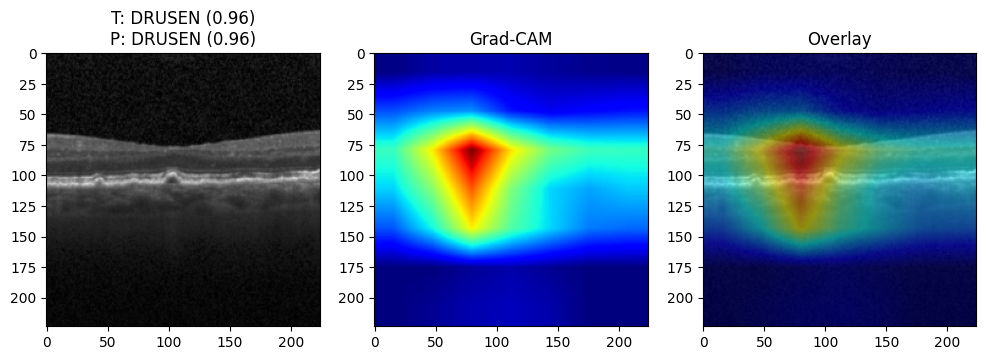

In [18]:
# Combined Sample Collection
wrong_samples = []
correct_samples = {}
threshold = 0.9

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        probs = torch.softmax(model(images), dim=1)
        preds = probs.argmax(dim=1)

        for i in range(len(labels)):
            p_idx, t_idx = preds[i].item(), labels[i].item()
            conf = probs[i][p_idx].item()
            t_conf = probs[i][t_idx].item()

            # Grab high-conf errors
            if p_idx != t_idx and conf > threshold and len(wrong_samples) < 4:
                wrong_samples.append((images[i].cpu(), t_idx, p_idx, conf, t_conf))

            # Grab 1 correct per class
            if p_idx == t_idx and conf > threshold and t_idx not in correct_samples:
                correct_samples[t_idx] = (images[i].cpu(), t_idx, p_idx, conf, t_conf)

for folder in [f"{path_plots}/gradcam_wrong", f"{path_plots}/gradcam_correct"]: os.makedirs(folder, exist_ok=True)

for i, (img, t, p, pc, tc) in enumerate(wrong_samples):
    cam = utils.generate_gradcam(model, img, p, device)
    utils.visualize_gradcam(img, cam, class_names[t], class_names[p], pc, tc, f"{path_plots}/gradcam_wrong/wrong_{i}.png")

for t_idx, (img, t, p, pc, tc) in correct_samples.items():
    cam = utils.generate_gradcam(model, img, p, device)
    utils.visualize_gradcam(img, cam, class_names[t], class_names[p], pc, tc, f"{path_plots}/gradcam_correct/correct_{class_names[t]}.png")